# Frontal-Plane Axis Rotation Demo

This notebook loads a preprocessed 12-lead ECG `.pt` tensor, applies a small frontal-plane
axis rotation (limb leads only), and plots the original vs rotated signals.

Notes:
- This is **not** a full 3D rotation; it only rotates I/aVF in the frontal plane.
- Precordial leads V1-V6 are left unchanged.
- Adjust `lead_order` if your channel ordering differs.


In [74]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Paths to three ECG tensors saved as .pt (shape [C,T] or [1,C,T])
ecg_samples = [
    {
        "path": "/home/flo178/projects/master-thesis/datasets/physionet2025/processedMaster/bp_sc_norm/1412187.pt",
        "label": "CODE-15 healthy",
    },
    {
        "path": "/home/flo178/projects/master-thesis/datasets/physionet2025/processedMaster/bp_sc_norm/13625_hr.pt",
        "label": "PTB-XL healthy",
    },
    {
        "path": "/home/flo178/projects/master-thesis/datasets/physionet2025/processedMaster/bp_sc_norm/59038.pt",
        "label": "SaMi-Trop Chagas",
    },
]

ecgs = []
for sample in ecg_samples:
    ecg_i = torch.load(sample["path"])
    if ecg_i.ndim == 3:
        ecg_i = ecg_i[0]
    ecgs.append(ecg_i.detach().cpu().numpy())

for i, (e, sample) in enumerate(zip(ecgs, ecg_samples)):
    print(f"ECG {i} ({sample['label']}) shape: {e.shape}")

# Adjust this if your channel ordering differs
lead_order = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

# Which ECG to visualize in 2D lead plots
plot_idx = 0
ecg = ecgs[plot_idx]


ECG 0 (CODE-15 healthy) shape: (12, 4096)
ECG 1 (PTB-XL healthy) shape: (12, 4000)
ECG 2 (SaMi-Trop Chagas) shape: (12, 2934)


In [75]:
def rotate_frontal_plane(ecg_in, angle_deg, lead_order):
    """Rotate limb leads in the frontal plane using I and aVF.
    ecg_in: [C,T] numpy array
    angle_deg: rotation angle in degrees (positive = CCW)
    lead_order: list of lead names matching channel order
    """
    ecg_out = ecg_in.copy()

    idx = {name: i for i, name in enumerate(lead_order)}
    for name in ["I", "II", "III", "aVR", "aVL", "aVF"]:
        if name not in idx:
            raise ValueError(f"Missing lead '{name}' in lead_order")

    I = ecg_in[idx["I"]]
    II = ecg_in[idx["II"]]
    # aVF computed from I and II
    aVF = II - 0.5 * I

    theta = np.deg2rad(angle_deg)
    c, s = np.cos(theta), np.sin(theta)
    I_rot = c * I - s * aVF
    aVF_rot = s * I + c * aVF

    II_rot = aVF_rot + 0.5 * I_rot
    III_rot = II_rot - I_rot
    aVR_rot = -(I_rot + II_rot) / 2.0
    aVL_rot = I_rot - 0.5 * II_rot

    ecg_out[idx["I"]] = I_rot
    ecg_out[idx["II"]] = II_rot
    ecg_out[idx["III"]] = III_rot
    ecg_out[idx["aVR"]] = aVR_rot
    ecg_out[idx["aVL"]] = aVL_rot
    ecg_out[idx["aVF"]] = aVF_rot

    return ecg_out


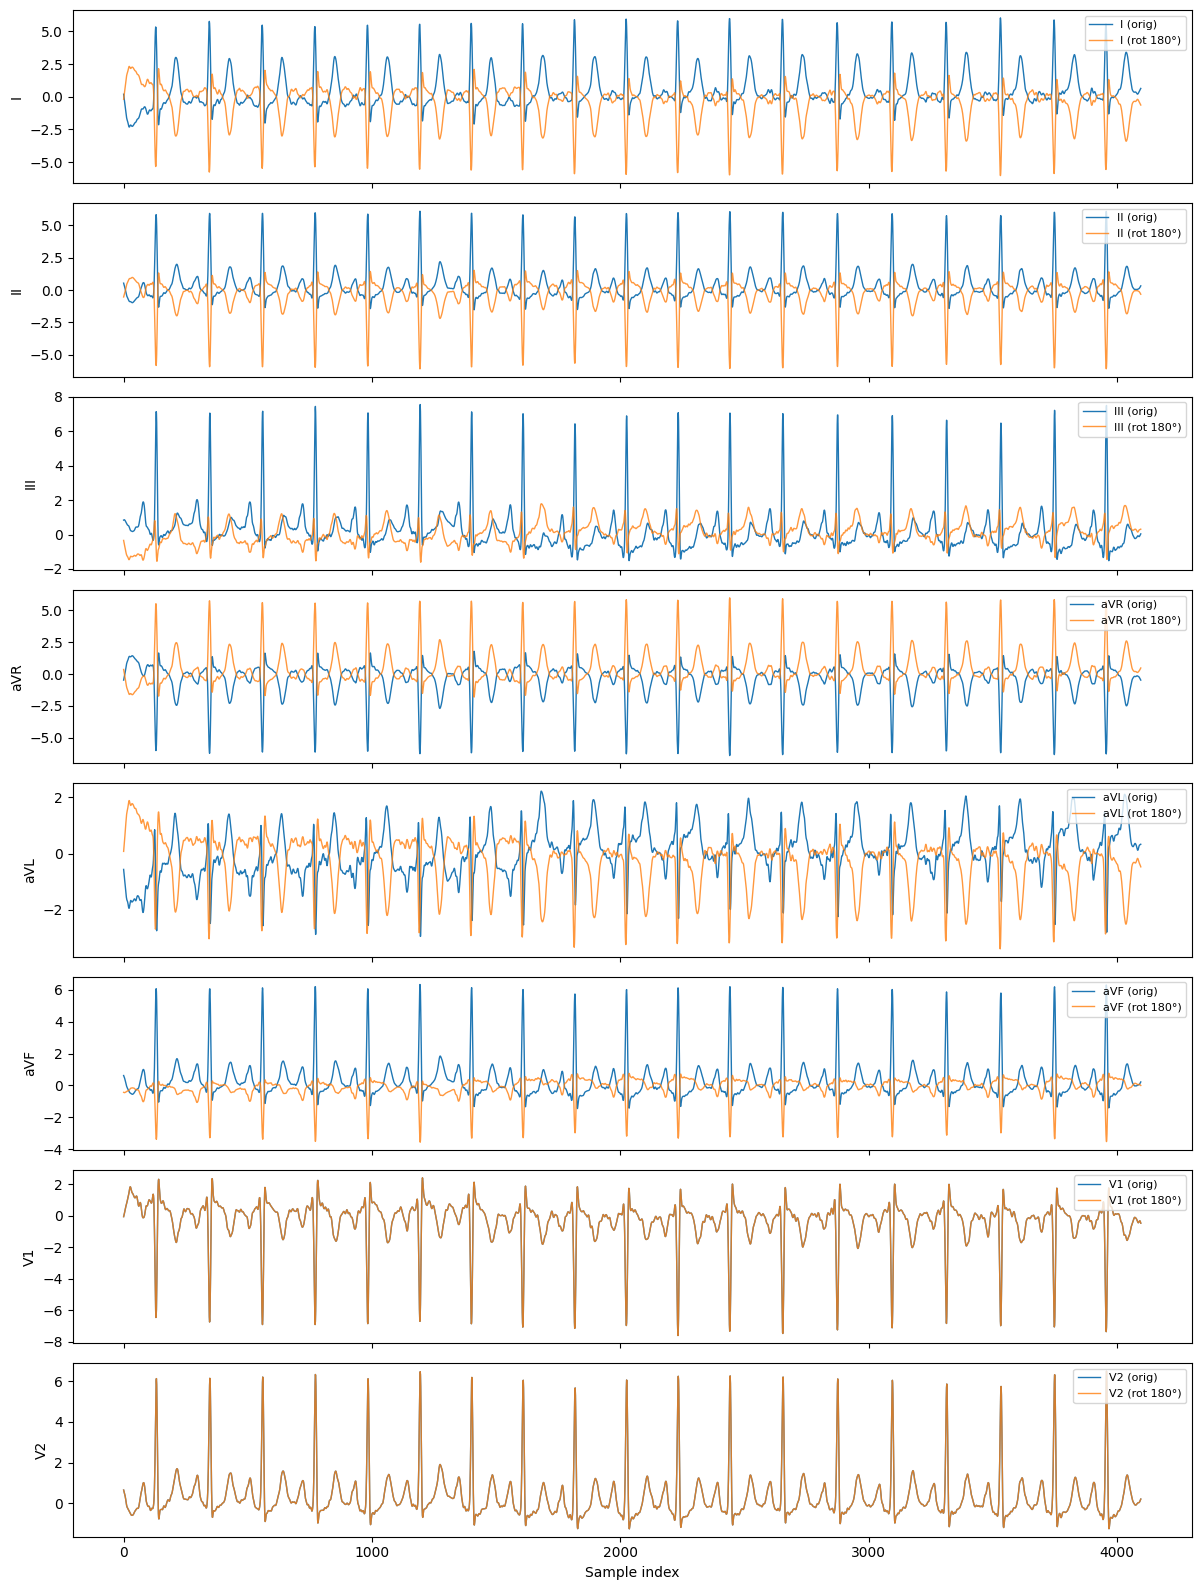

In [76]:
angle_deg = 180  # rotation angle for frontal-plane demo
ecg_rots = [rotate_frontal_plane(e, angle_deg, lead_order) for e in ecgs]
ecg_rot = ecg_rots[plot_idx]

# Plot a subset of leads
plot_leads = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2"]
n = len(plot_leads)
fig, axes = plt.subplots(n, 1, figsize=(12, 2 * n), sharex=True)
if n == 1:
    axes = [axes]

t = np.arange(ecg.shape[1])
for ax, name in zip(axes, plot_leads):
    idx = lead_order.index(name)
    ax.plot(t, ecg[idx], label=f"{name} (orig)", linewidth=1)
    ax.plot(t, ecg_rot[idx], label=f"{name} (rot {angle_deg}°)", linewidth=1, alpha=0.8)
    ax.set_ylabel(name)
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Sample index")
plt.tight_layout()


In [77]:
def estimate_frontal_axis_deg(ecg_in, lead_order):
    """Rough frontal-plane axis (deg) using peak-to-peak QRS proxy.
    Note: for accuracy, segment QRS and compute mean QRS vector.
    """
    idx = {name: i for i, name in enumerate(lead_order)}
    I = ecg_in[idx["I"]]
    II = ecg_in[idx["II"]]
    aVF = II - 0.5 * I

    vec_I = I.max() - I.min()
    vec_aVF = aVF.max() - aVF.min()

    angle = np.degrees(np.arctan2(vec_aVF, vec_I))
    return angle

print("Estimated frontal QRS axis (deg):")
for i, (e_orig, e_rot) in enumerate(zip(ecgs, ecg_rots)):
    ang_orig = estimate_frontal_axis_deg(e_orig, lead_order)
    ang_rot = estimate_frontal_axis_deg(e_rot, lead_order)
    print(f"ECG {i}: orig={ang_orig:.1f}°, rot={ang_rot:.1f}°")


Estimated frontal QRS axis (deg):
ECG 0: orig=27.4°, rot=27.4°
ECG 1: orig=49.7°, rot=49.7°
ECG 2: orig=37.4°, rot=37.4°


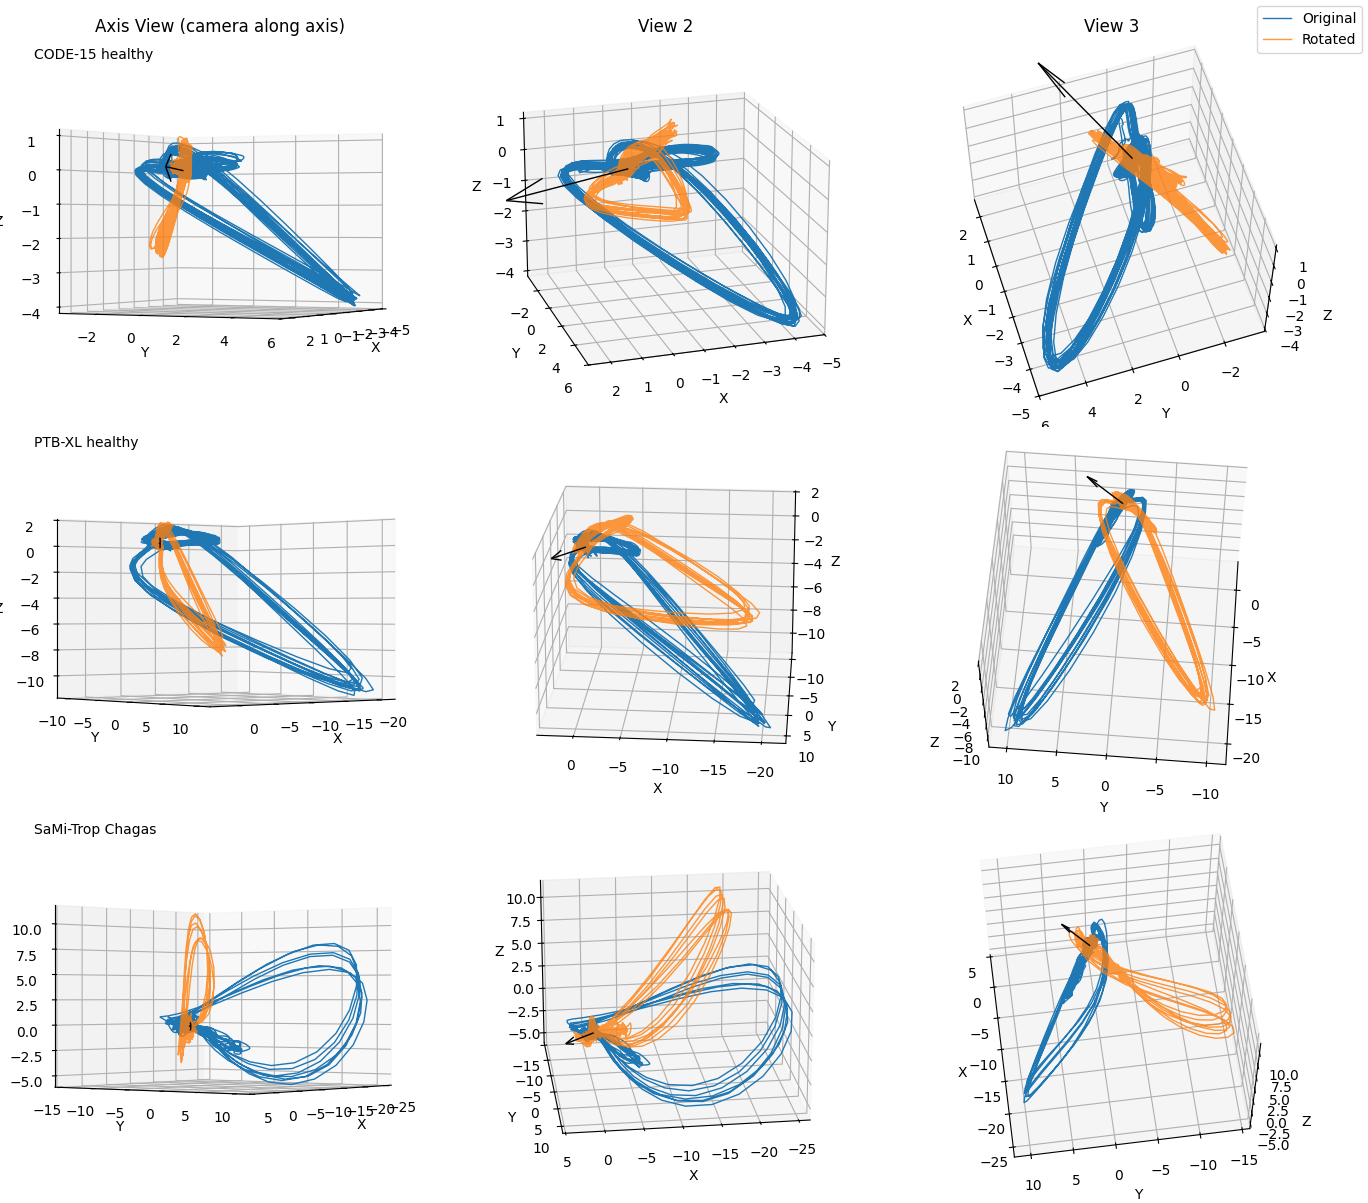

In [78]:
def compute_frank_xyz(ecg_in, lead_order):
    """Compute Frank XYZ from 12-lead ECG using a linear approximation.
    This uses the coefficients from Wikipedia (Dower-like transform).
    """
    idx = {name: i for i, name in enumerate(lead_order)}
    for name in ["I", "II", "V1", "V2", "V3", "V4", "V5", "V6"]:
        if name not in idx:
            raise ValueError(f"Missing lead '{name}' in lead_order")

    I = ecg_in[idx["I"]]
    II = ecg_in[idx["II"]]
    V1 = ecg_in[idx["V1"]]
    V2 = ecg_in[idx["V2"]]
    V3 = ecg_in[idx["V3"]]
    V4 = ecg_in[idx["V4"]]
    V5 = ecg_in[idx["V5"]]
    V6 = ecg_in[idx["V6"]]

    # Frank leads approximation (as provided)
    X = -(-0.172 * V1 - 0.074 * V2 + 0.122 * V3 + 0.231 * V4 + 0.239 * V5 + 0.194 * V6 + 0.156 * I - 0.010 * II)
    Y = (0.057 * V1 - 0.019 * V2 - 0.106 * V3 - 0.022 * V4 + 0.041 * V5 + 0.048 * V6 - 0.227 * I + 0.887 * II)
    Z = -(-0.229 * V1 - 0.310 * V2 - 0.246 * V3 - 0.063 * V4 + 0.055 * V5 + 0.108 * V6 + 0.022 * I + 0.102 * II)
    return X, Y, Z

def estimate_frontal_axis_vector(ecg_in, lead_order):
    idx = {name: i for i, name in enumerate(lead_order)}
    I = ecg_in[idx["I"]]
    II = ecg_in[idx["II"]]
    aVF = II - 0.5 * I
    vec_I = I.max() - I.min()
    vec_aVF = aVF.max() - aVF.min()
    norm = np.hypot(vec_I, vec_aVF) or 1.0
    return vec_I / norm, vec_aVF / norm

# 3x3 grid: rows = ECG samples, cols = 3 views
titles = ["Axis View (camera along axis)", "View 2", "View 3"]

fig = plt.figure(figsize=(14, 12))
for row_idx, (e_orig, e_rot) in enumerate(zip(ecgs, ecg_rots)):
    xyz_orig = compute_frank_xyz(e_orig, lead_order)
    xyz_rot = compute_frank_xyz(e_rot, lead_order)

    ax_i, ax_avf = estimate_frontal_axis_vector(e_orig, lead_order)
    base_azim = np.degrees(np.arctan2(ax_avf, ax_i))
    views = [
        (0, base_azim),
        (20, base_azim + 45),
        (60, base_azim + 135),
    ]

    for col_idx, (elev, azim) in enumerate(views):
        ax = fig.add_subplot(3, 3, row_idx * 3 + col_idx + 1, projection="3d")
        ax.plot(*xyz_orig, label="Original", linewidth=1)
        ax.plot(*xyz_rot, label="Rotated", linewidth=1, alpha=0.8)
        # Add frontal-plane axis vector (projected on X-Y)
        ax.quiver(0, 0, 0, ax_i, ax_avf, 0, length=5.0, color='k', linewidth=1)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.view_init(elev=elev, azim=azim)
        if row_idx == 0:
            ax.set_title(titles[col_idx])
        if col_idx == 0:
            ax.text2D(0.0, 0.95, ecg_samples[row_idx]['label'], transform=ax.transAxes)

# Single shared legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
